In [ ]:
!pip install mediapipe==0.10.14 Pillow==10.4.0 torchvision -q

W0000 00:00:1773918137.711867     185 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773918137.722464     185 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


🕵️ Bắt đầu quét bề mặt 348 video để đo đạc MAR...


  0%|          | 0/348 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
100%|██████████| 348/348 [07:18<00:00,  1.26s/it]



📊 Đang vẽ biểu đồ phân phối...


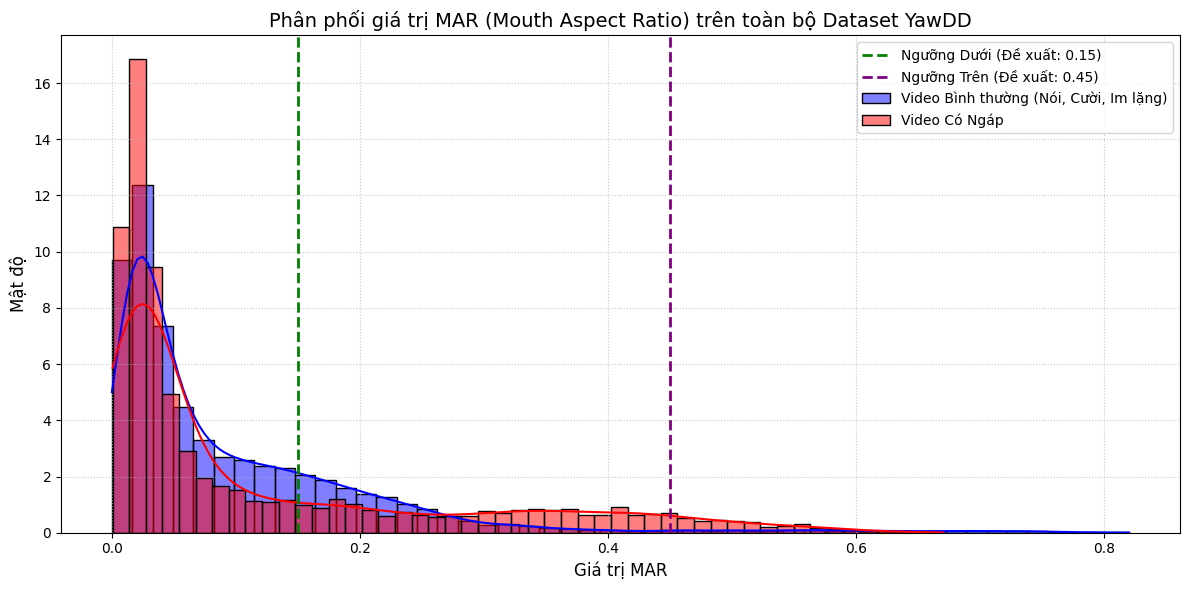


📝 THỐNG KÊ TOÁN HỌC:
Video Bình thường - MAR Max: 0.820 | Percentile 95%: 0.286
Video Ngáp        - MAR Max: 0.670 | Percentile 95%: 0.452


In [3]:
import cv2
import mediapipe as mp
import os
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ==========================================
# 1. CẤU HÌNH VÀ KHỞI TẠO
# ==========================================
ROOT_DIR = '/kaggle/input/datasets/enider/yawdd-dataset' 
FRAME_SKIP = 10 # Quét nhanh mỗi giây khoảng 3 frame (video 30fps)

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=False, max_num_faces=1, refine_landmarks=False)

def calculate_mar(landmarks, w, h):
    p_left = (landmarks.landmark[61].x * w, landmarks.landmark[61].y * h)
    p_right = (landmarks.landmark[291].x * w, landmarks.landmark[291].y * h)
    p_top = (landmarks.landmark[13].x * w, landmarks.landmark[13].y * h)
    p_bottom = (landmarks.landmark[14].x * w, landmarks.landmark[14].y * h)
    
    dist_h = math.hypot(p_right[0] - p_left[0], p_right[1] - p_left[1])
    dist_v = math.hypot(p_bottom[0] - p_top[0], p_bottom[1] - p_top[1])
    return dist_v / dist_h if dist_h > 0 else 0.0

# ==========================================
# 2. THU THẬP DỮ LIỆU
# ==========================================
mar_yawn_videos = []   # Chứa MAR của các video có hành động ngáp
mar_normal_videos = [] # Chứa MAR của các video bình thường (nói chuyện, cười, im lặng)

all_videos = []
for root, dirs, files in os.walk(ROOT_DIR):
    for file in files:
        if file.lower().endswith('.avi'):
            all_videos.append(os.path.join(root, file))

print(f"🕵️ Bắt đầu quét bề mặt {len(all_videos)} video để đo đạc MAR...")

for video_path in tqdm(all_videos):
    video_name = os.path.basename(video_path)
    is_yawn_video = 'yawn' in video_name.lower()
    
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        frame_count += 1
        if frame_count % FRAME_SKIP != 0: continue
            
        h, w, _ = frame.shape
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_frame)
        
        if results.multi_face_landmarks:
            mar_value = calculate_mar(results.multi_face_landmarks[0], w, h)
            
            if is_yawn_video:
                mar_yawn_videos.append(mar_value)
            else:
                mar_normal_videos.append(mar_value)

    cap.release()

# ==========================================
# 3. VẼ BIỂU ĐỒ PHÂN PHỐI (HISTOGRAM)
# ==========================================
print("\n📊 Đang vẽ biểu đồ phân phối...")
plt.figure(figsize=(12, 6))

# Vẽ KDE (Đường cong phân phối) và Histogram
sns.histplot(mar_normal_videos, color='blue', label='Video Bình thường (Nói, Cười, Im lặng)', kde=True, stat="density", bins=50, alpha=0.5)
sns.histplot(mar_yawn_videos, color='red', label='Video Có Ngáp', kde=True, stat="density", bins=50, alpha=0.5)

plt.title('Phân phối giá trị MAR (Mouth Aspect Ratio) trên toàn bộ Dataset YawDD', fontsize=14)
plt.xlabel('Giá trị MAR', fontsize=12)
plt.ylabel('Mật độ', fontsize=12)

# Vẽ các đường tham chiếu dự kiến
plt.axvline(x=0.15, color='green', linestyle='--', linewidth=2, label='Ngưỡng Dưới (Đề xuất: 0.15)')
plt.axvline(x=0.45, color='purple', linestyle='--', linewidth=2, label='Ngưỡng Trên (Đề xuất: 0.45)')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Lưu và hiển thị
plt.savefig('mar_distribution_histogram.png', dpi=300)
plt.show()

# In thống kê cơ bản
print("\n📝 THỐNG KÊ TOÁN HỌC:")
print(f"Video Bình thường - MAR Max: {max(mar_normal_videos):.3f} | Percentile 95%: {np.percentile(mar_normal_videos, 95):.3f}")
print(f"Video Ngáp        - MAR Max: {max(mar_yawn_videos):.3f} | Percentile 95%: {np.percentile(mar_yawn_videos, 95):.3f}")